In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('../data/images/test.jpg')
if img is None:
    raise FileNotFoundError("check the path")

print("shape:", img.shape)      # (h, w, 3)
print("dtype:", img.dtype)      # uint8
print("min/max:", img.min(), img.max())
print("pixel at (100,50):", img[100, 50])   # [B G R]

shape: (477, 500, 3)
dtype: uint8
min/max: 0 255
pixel at (100,50): [255 255 255]


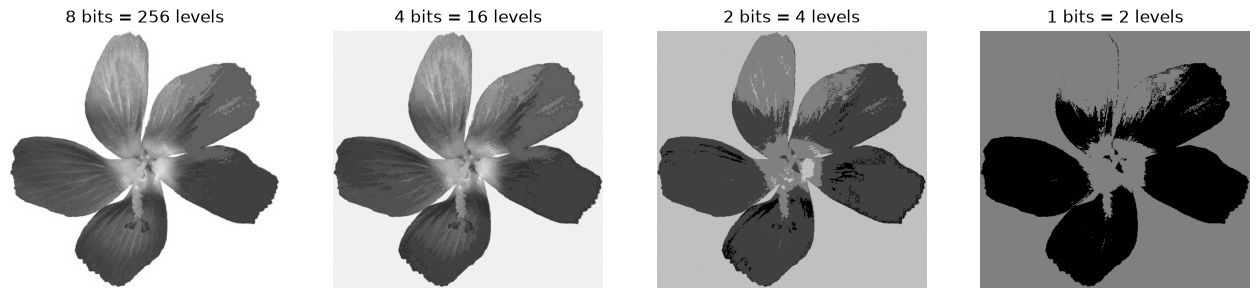

In [5]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, bits in zip(axes, [8, 4, 2, 1]):
    levels = 2 ** bits
    step = 256 // levels
    q = (gray // step) * step          # crush to fewer levels
    ax.imshow(q, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f"{bits} bits = {levels} levels")
    ax.axis('off')
plt.show()

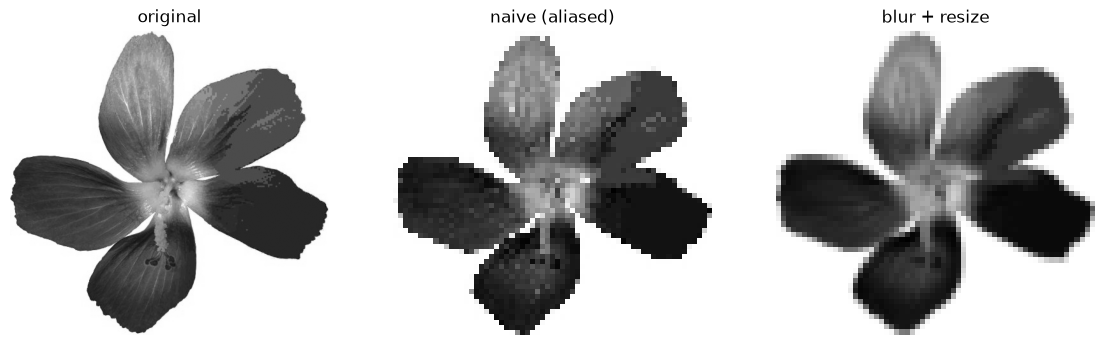

In [6]:
h, w = gray.shape

naive = gray[::8, ::8]                                  # just throw pixels away
proper = cv2.resize(cv2.GaussianBlur(gray, (9, 9), 0),  # blur first
                    (w // 8, h // 8), interpolation=cv2.INTER_AREA)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, im, t in zip(axes, [gray, naive, proper],
                     ["original", "naive (aliased)", "blur + resize"]):
    ax.imshow(im, cmap='gray'); ax.set_title(t); ax.axis('off')
plt.show()

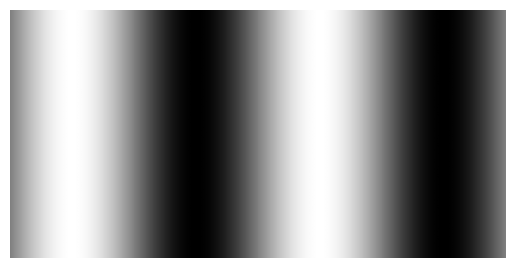

In [7]:
x = np.linspace(0, 4 * np.pi, 512)
ramp = np.tile(((np.sin(x) + 1) * 127.5).astype(np.uint8), (256, 1))
plt.imshow(ramp, cmap='gray'); plt.axis('off'); plt.show()